In [1]:
%load_ext autoreload
%autoreload 2
import pandas as pd
from src.config import *
from src.utils import *
from src.feature_extraction import *

In [2]:
gt_subset = pd.read_csv(BINARY_GT_TRAIN_SUBSET_CSV)
sample = gt_subset.groupby("label").sample(200, random_state=RANDOM_STATE)

rows = []
for r in sample.itertuples():
    img = load_preprocessed(r.filename, r.label, BINARY_PREPROC_TRAIN_DIR)
    rows.append({"filename": r.filename, "label": r.label, **extract_features(img)})

df = pd.DataFrame(rows)
df.shape    # should be (400, 180)

(400, 180)

In [3]:
feature_groups = {
    "color_moments": [c for c in df.columns if c.startswith(("rgb_", "hsv_", "lab_"))],
    "color_hist":    [c for c in df.columns if c.startswith("hist_")],
    "lbp":           [c for c in df.columns if c.startswith("lbp_")],
    "glcm":          [c for c in df.columns if c.startswith("glcm_")],
}
for name, cols in feature_groups.items():
    print(f"{name}: {len(cols)} features")

color_moments: 36 features
color_hist: 96 features
lbp: 28 features
glcm: 18 features


In [4]:
group = "color_moments"
cols = feature_groups[group]

stats = df[cols].describe().T
stats["n_nan"] = df[cols].isna().sum()
stats.round(3)

,count,mean,std,min,25%,50%,75%,max,n_nan
rgb_r_mean,400.0,166.415,21.111,76.206,152.292,168.606,181.500,233.295,0
rgb_r_std,400.0,16.453,10.565,2.228,8.664,13.327,21.285,62.956,0
rgb_r_skew,400.0,-1.647,1.341,-7.912,-2.319,-1.442,-0.767,2.490,0
rgb_r_kurt,400.0,6.670,12.987,-1.609,0.227,2.707,8.349,169.682,0
rgb_g_mean,400.0,160.239,21.868,79.995,145.390,162.394,176.055,232.532,0
rgb_g_std,400.0,28.392,12.593,5.962,18.863,26.615,36.488,76.029,0
rgb_g_skew,400.0,-1.099,1.082,-5.165,-1.654,-0.899,-0.437,2.741,0
rgb_g_kurt,400.0,2.388,5.269,-1.597,-0.436,0.524,2.766,37.245,0
rgb_b_mean,400.0,157.349,22.381,67.518,142.320,158.791,173.784,232.410,0
rgb_b_std,400.0,32.453,13.293,7.090,22.807,29.976,40.411,84.815,0


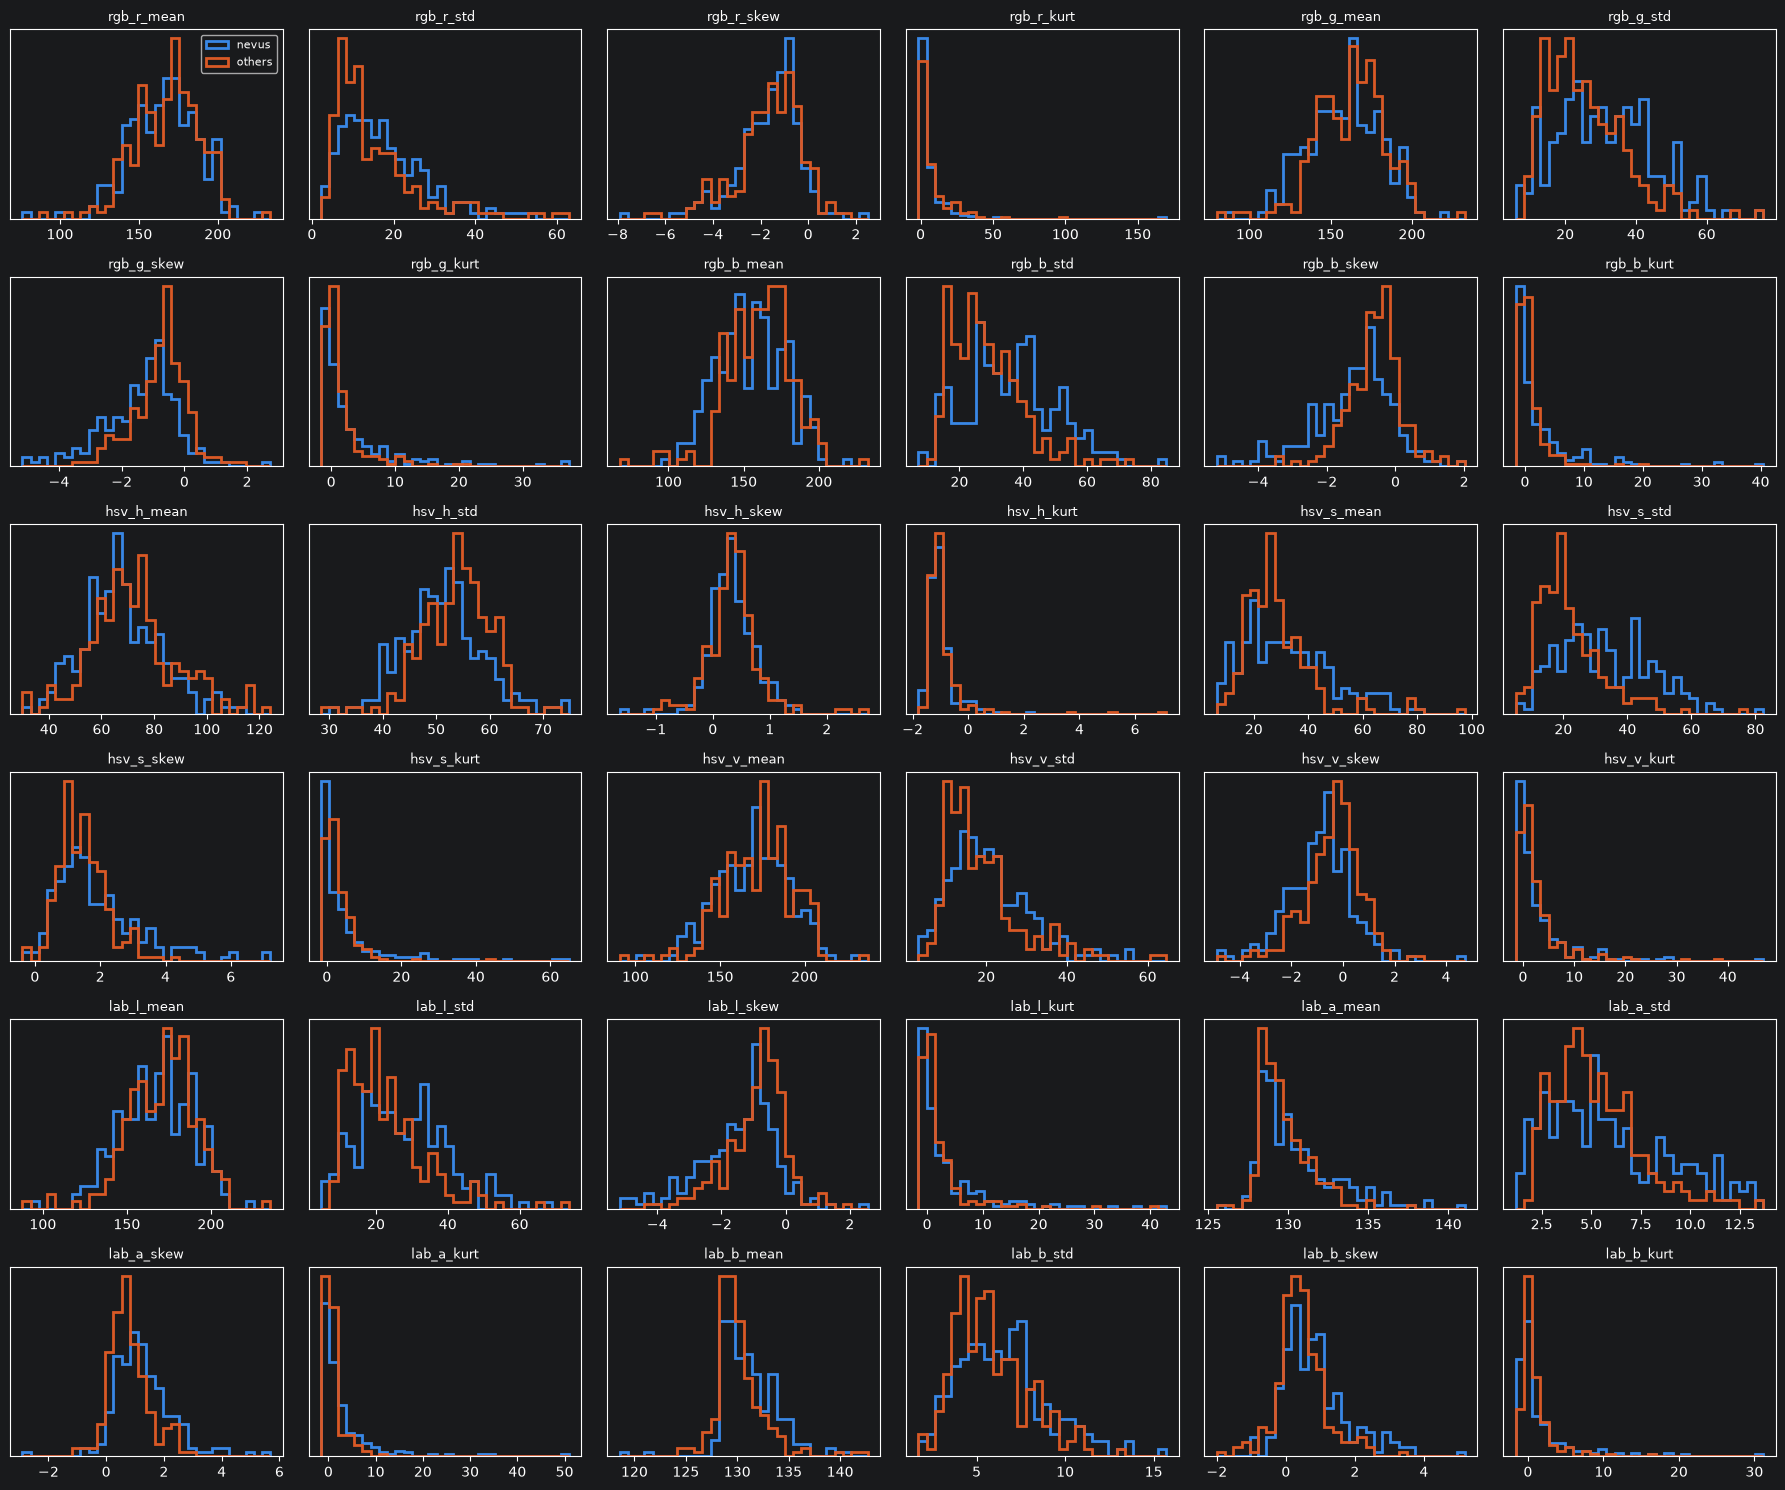

In [5]:
plot_feature_distributions(df, feature_groups["color_moments"])

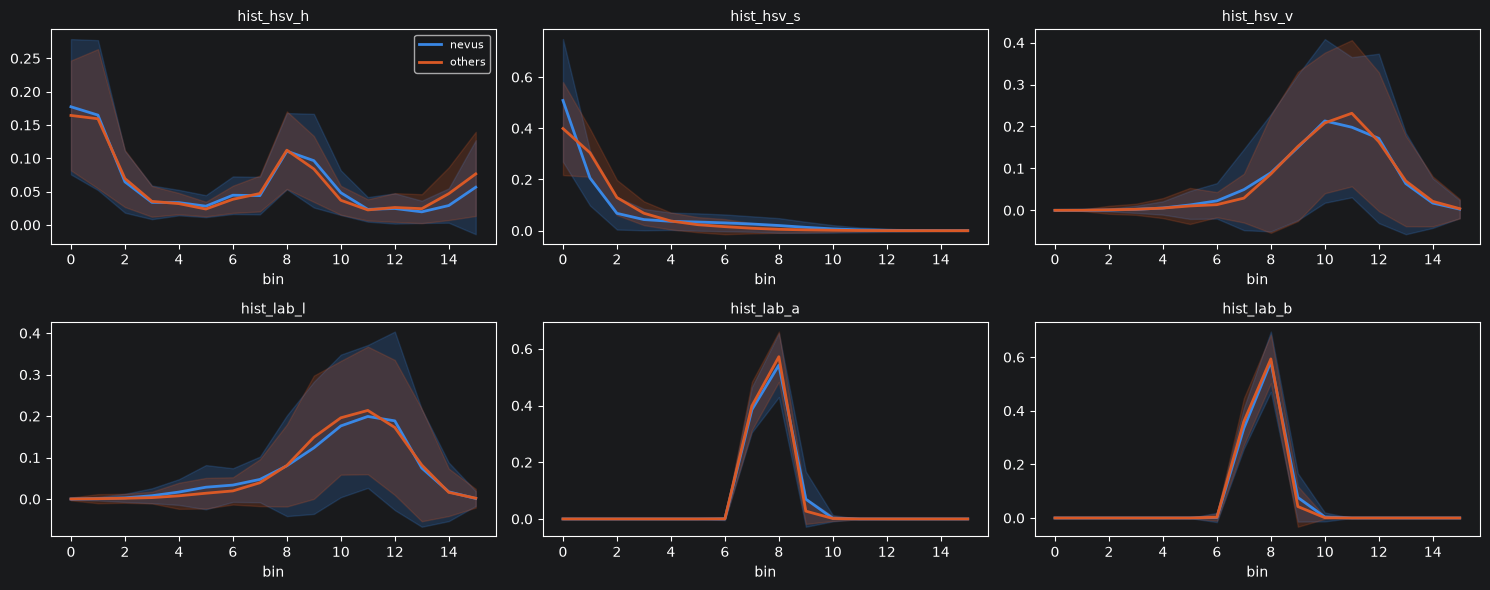

In [6]:
plot_mean_histograms(df, ["hist_hsv_h_", "hist_hsv_s_", "hist_hsv_v_",
                          "hist_lab_l_", "hist_lab_a_", "hist_lab_b_"])

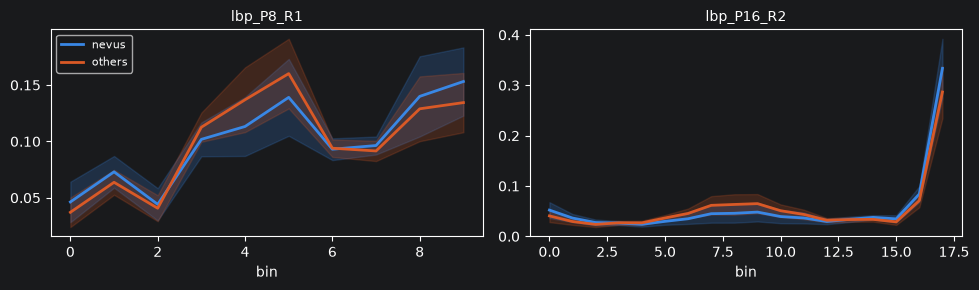

In [7]:
plot_mean_histograms(df, ["lbp_P8_R1_", "lbp_P16_R2_"], ncols=2)

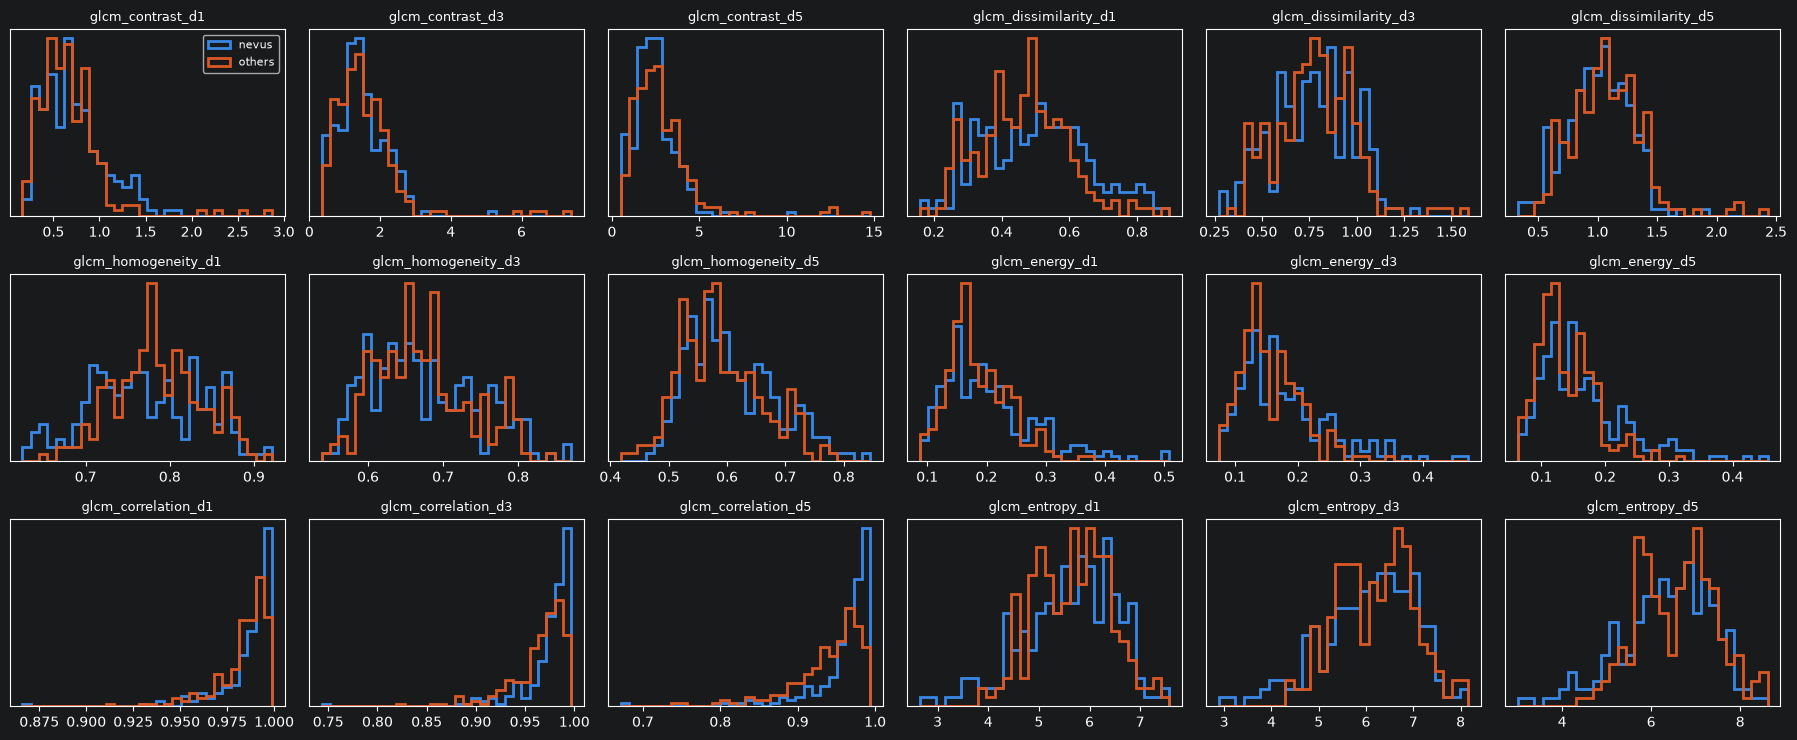

In [8]:
plot_feature_distributions(df, feature_groups["glcm"])